# StarDist Segmentation — BBBC020 DAPI Images

## Overview
This notebook runs StarDist2D on DAPI-stained fluorescence microscopy images 
from the BBBC020 dataset (murine bone marrow macrophages). StarDist is configured 
for single-channel 2D images using the pretrained `2D_versatile_fluo` model, which 
was trained on fluorescence microscopy data and is well-suited for DAPI-stained nuclei.

Outputs include:
- Segmentation masks overlaid on raw images across four time points (30 min, 1h, 2h, 24h)
- A 200×200 crop for visual mask quality inspection
- Cells per Pixel (Cf/P), a normalized metric for comparing cell density across 
  segmentation methods and experimental conditions

-------------------------------------------------------------------------------------------------------------------------------

## Data

Images are from the **BBBC020** dataset (Broad Bioimage Benchmark Collection), 
a publicly available set of fluorescence microscopy images of murine bone marrow 
derived macrophages stained with DAPI (c1 channel) and CD11b/APC (c5 channel).

Four time points were selected to represent the full experimental time course:
- `jw-30min 5_c1.TIF` — 30 minutes post-treatment
- `jw-1h 1_c1.TIF` — 1 hour post-treatment
- `jw-2h 2_c1.TIF` — 2 hours post-treatment
- `jw-24h 4_c1.TIF` — 24 hours post-treatment

Each image is 1040 × 1388 pixels. Although saved as 3-channel TIFFs, all 
channels are identical — channel 0 (c1, DAPI) is extracted for analysis.

**Source:** https://bbbc.broadinstitute.org/BBBC020  
**License:** CC Attribution

In [33]:
import sys
import numpy as np
import matplotlib

import tensorflow as tf

# When matplotlib displays an image it tries to smooth it by default(turns that off)
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt

#display plots directly inside the notebook (Juypter command)
%matplotlib inline 

#makes images render at double resolution -> Without it images can look pixelated on mac
%config InlineBackend.figure_format = 'retina' 

from glob import glob
from tifffile import imread
from csbdeep.utils import Path, normalize
from csbdeep.io import save_tiff_imagej_compatible

from stardist import random_label_cmap, _draw_polygons, export_imagej_rois
from stardist.models import StarDist2D

np.random.seed(8)
lbl_cmap = random_label_cmap()
print(np.__version__, matplotlib.__version__, StarDist2D, lbl_cmap)

1.26.4 3.10.9 <class 'stardist.models.model2d.StarDist2D'> <matplotlib.colors.ListedColormap object at 0x7f6ef41215d0>


## Load Images

Images are loaded using `tifffile.imread` and converted to 2D grayscale arrays 
by extracting channel 0. Paths are defined explicitly in chronological order 
(30min → 1h → 2h → 24h) rather than using `glob` to ensure correct time ordering. 
Image dimensions are printed to confirm all four images are the same size.

-------------------------------------------------------------------------------------------------------------------------------
## Visualization

Raw images are displayed side by side in chronological order to inspect image 
quality and cell density across time points before segmentation. All four images 
are shown at the same scale for direct comparison.

Notable observations:
- The 30min image appears darker with lower signal intensity
- Cell density and morphology visibly change across time points
- Large bright streaks in some images may represent imaging artifacts or 
  out-of-focus regions

jw-30min 5_c1.TIF: (1040, 1388)
jw-1h 1_c1.TIF: (1040, 1388)
jw-2h 2_c1.TIF: (1040, 1388)
jw-24h 4_c1.TIF: (1040, 1388)


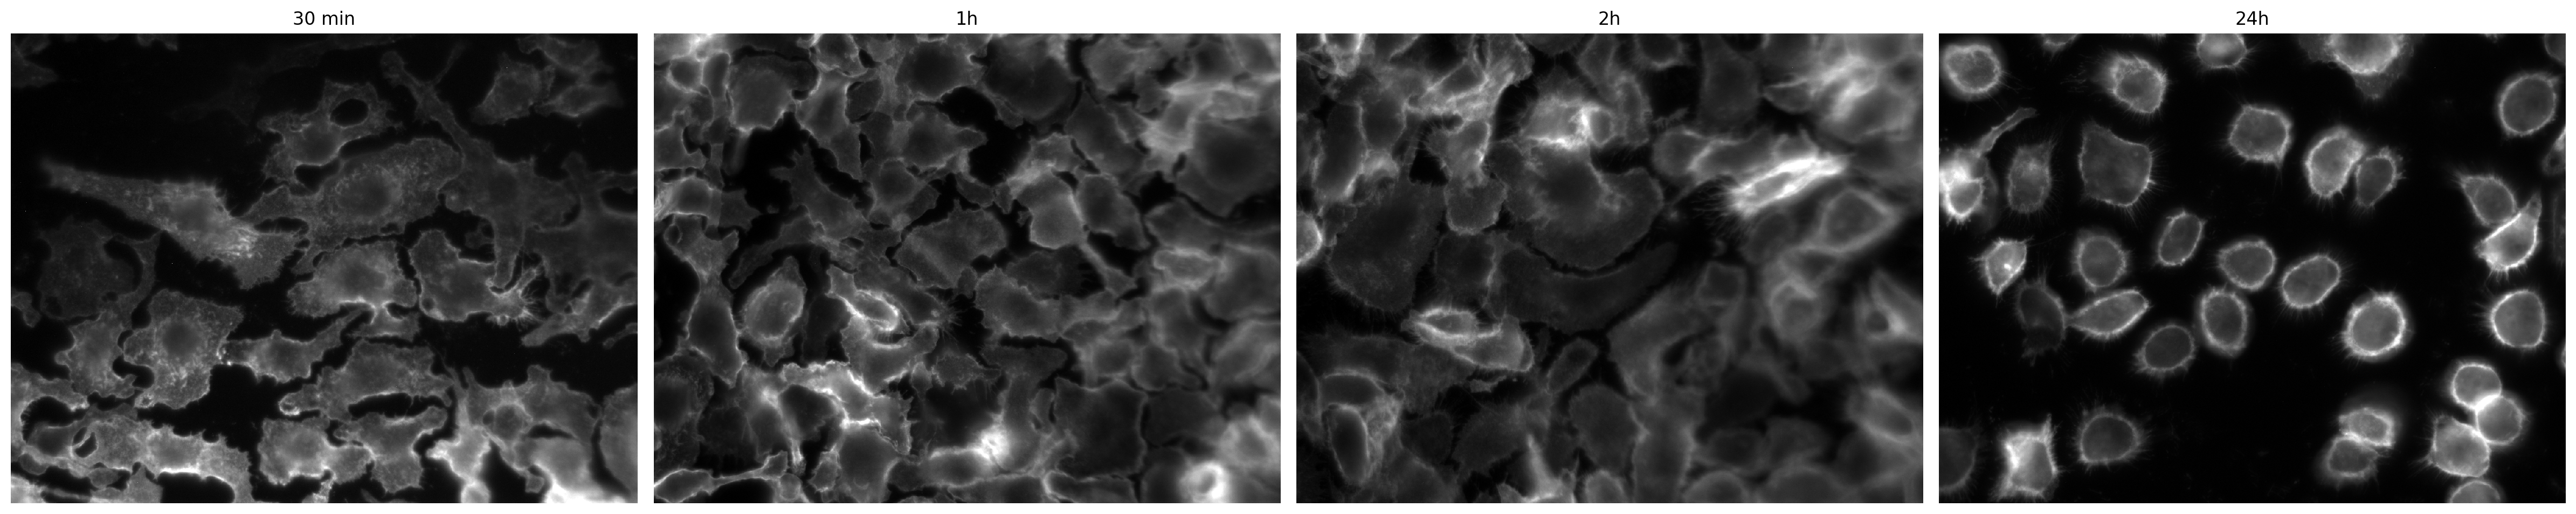

In [34]:
import matplotlib.pyplot as plt
from tifffile import imread
import numpy as np

# load all 4 images
image_paths = [
    "/ix/apoholek/mxie/Personal/jw-30min 5_c1.TIF",
    "/ix/apoholek/mxie/Personal/jw-1h 1_c1.TIF",
    "/ix/apoholek/mxie/Personal/jw-2h 2_c1.TIF",
    "/ix/apoholek/mxie/Personal/jw-24h 4_c1.TIF"
]

# take first channel only
images = [imread(p)[:, :, 0] for p in image_paths]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
titles = ['30 min', '1h', '2h', '24h']
 
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

#dimension check
for path, img in zip(image_paths, images):
    print(f"{path.split('/')[-1]}: {img.shape}")

plt.tight_layout()
plt.show()

## Model

StarDist2D is a deep learning segmentation method that represents each nucleus 
as a **star-convex polygon** — predicting distances from the cell center to the 
boundary in multiple directions (rays). This makes it well-suited for round or 
oval nuclei like DAPI-stained macrophage nuclei.

The pretrained `2D_versatile_fluo` model is used here, which was trained on 
diverse fluorescence microscopy images including DAPI-stained nuclei. Each image 
is normalized to the 1st–99.8th percentile range before inference, which is the 
recommended preprocessing step for StarDist.

**Key parameters:**
- Model: `2D_versatile_fluo`
- Normalization: `normalize(img, 1, 99.8)`
- `prob_thresh`: default (0.479) — controls detection sensitivity
- `nms_thresh`: default (0.3) — controls suppression of overlapping detections

In [16]:
StarDist2D.from_pretrained()

There are 4 registered models for 'StarDist2D':

Name                  Alias(es)
────                  ─────────
'2D_versatile_fluo'   'Versatile (fluorescent nuclei)'
'2D_versatile_he'     'Versatile (H&E nuclei)'
'2D_paper_dsb2018'    'DSB 2018 (from StarDist 2D paper)'
'2D_demo'             None


In [22]:
model = StarDist2D.from_pretrained('2D_versatile_fluo')

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


In [23]:
labels = []
polys = []

for img in images:
    img_norm = normalize(img, 1, 99.8, axis=(0,1))
    lbl, poly = model.predict_instances(img_norm)
    labels.append(lbl)
    polys.append(poly)
    print(f"Detected {lbl.max()} cells")

Detected 157 cells
Detected 252 cells
Detected 186 cells
Detected 61 cells


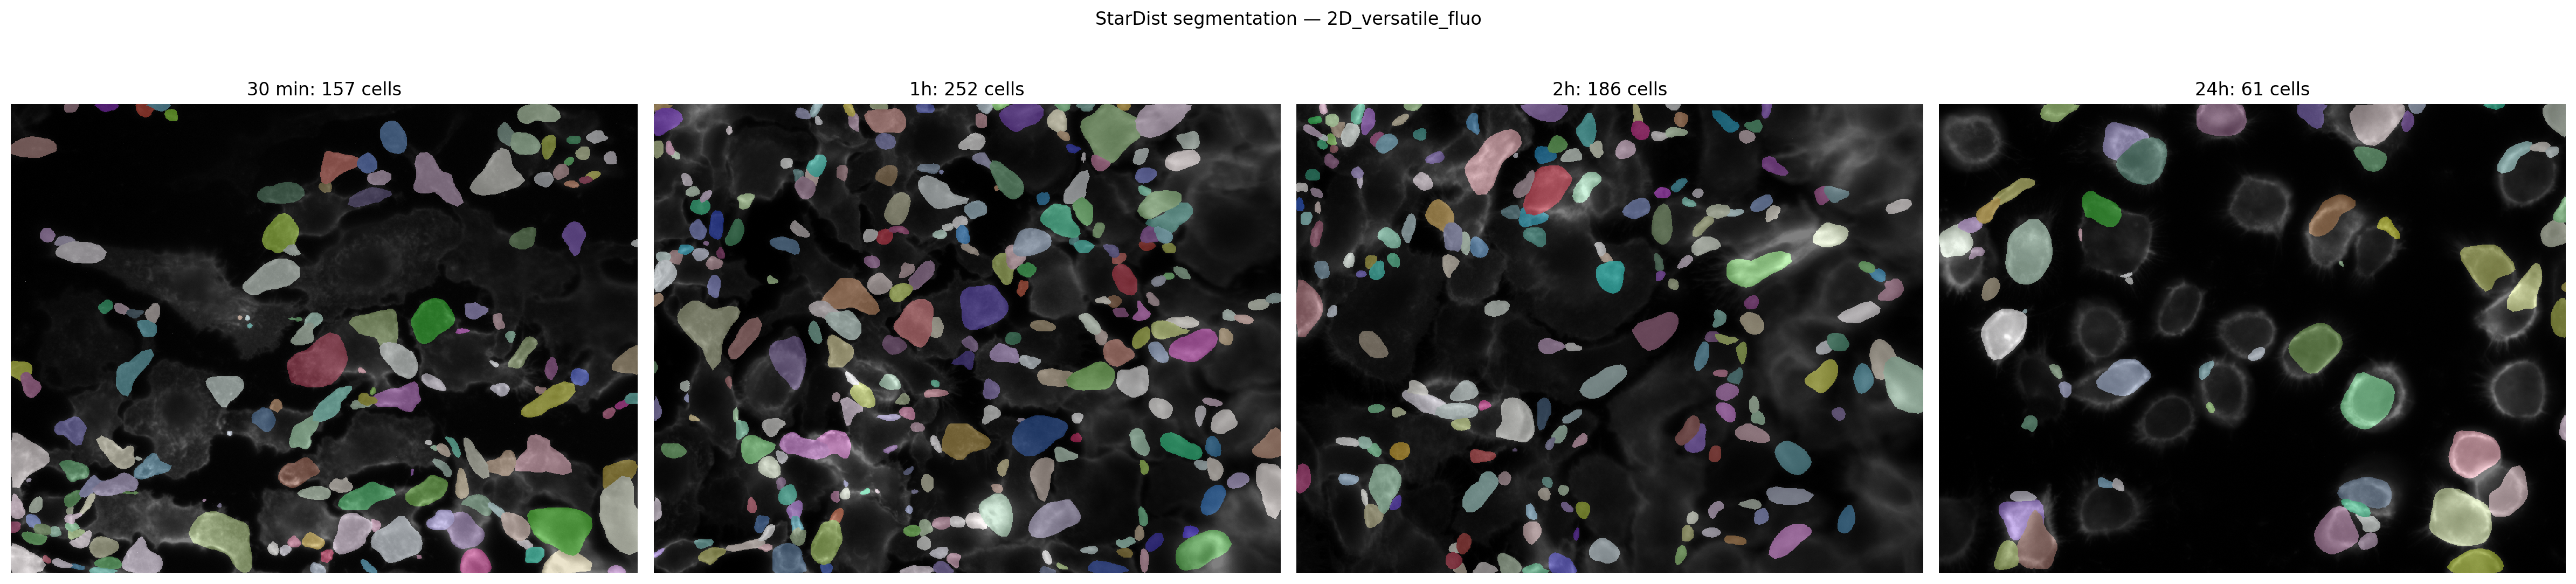

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, img, lbl, title in zip(axes, images, labels, titles):
    img_norm = normalize(img, 1, 99.8, axis=(0,1))
    ax.imshow(img_norm, cmap='gray')
    ax.imshow(lbl, cmap=lbl_cmap, alpha=0.5)
    ax.set_title(f'{title}: {lbl.max()} cells')
    ax.axis('off')
plt.suptitle('StarDist segmentation — 2D_versatile_fluo')
plt.tight_layout()
plt.show()

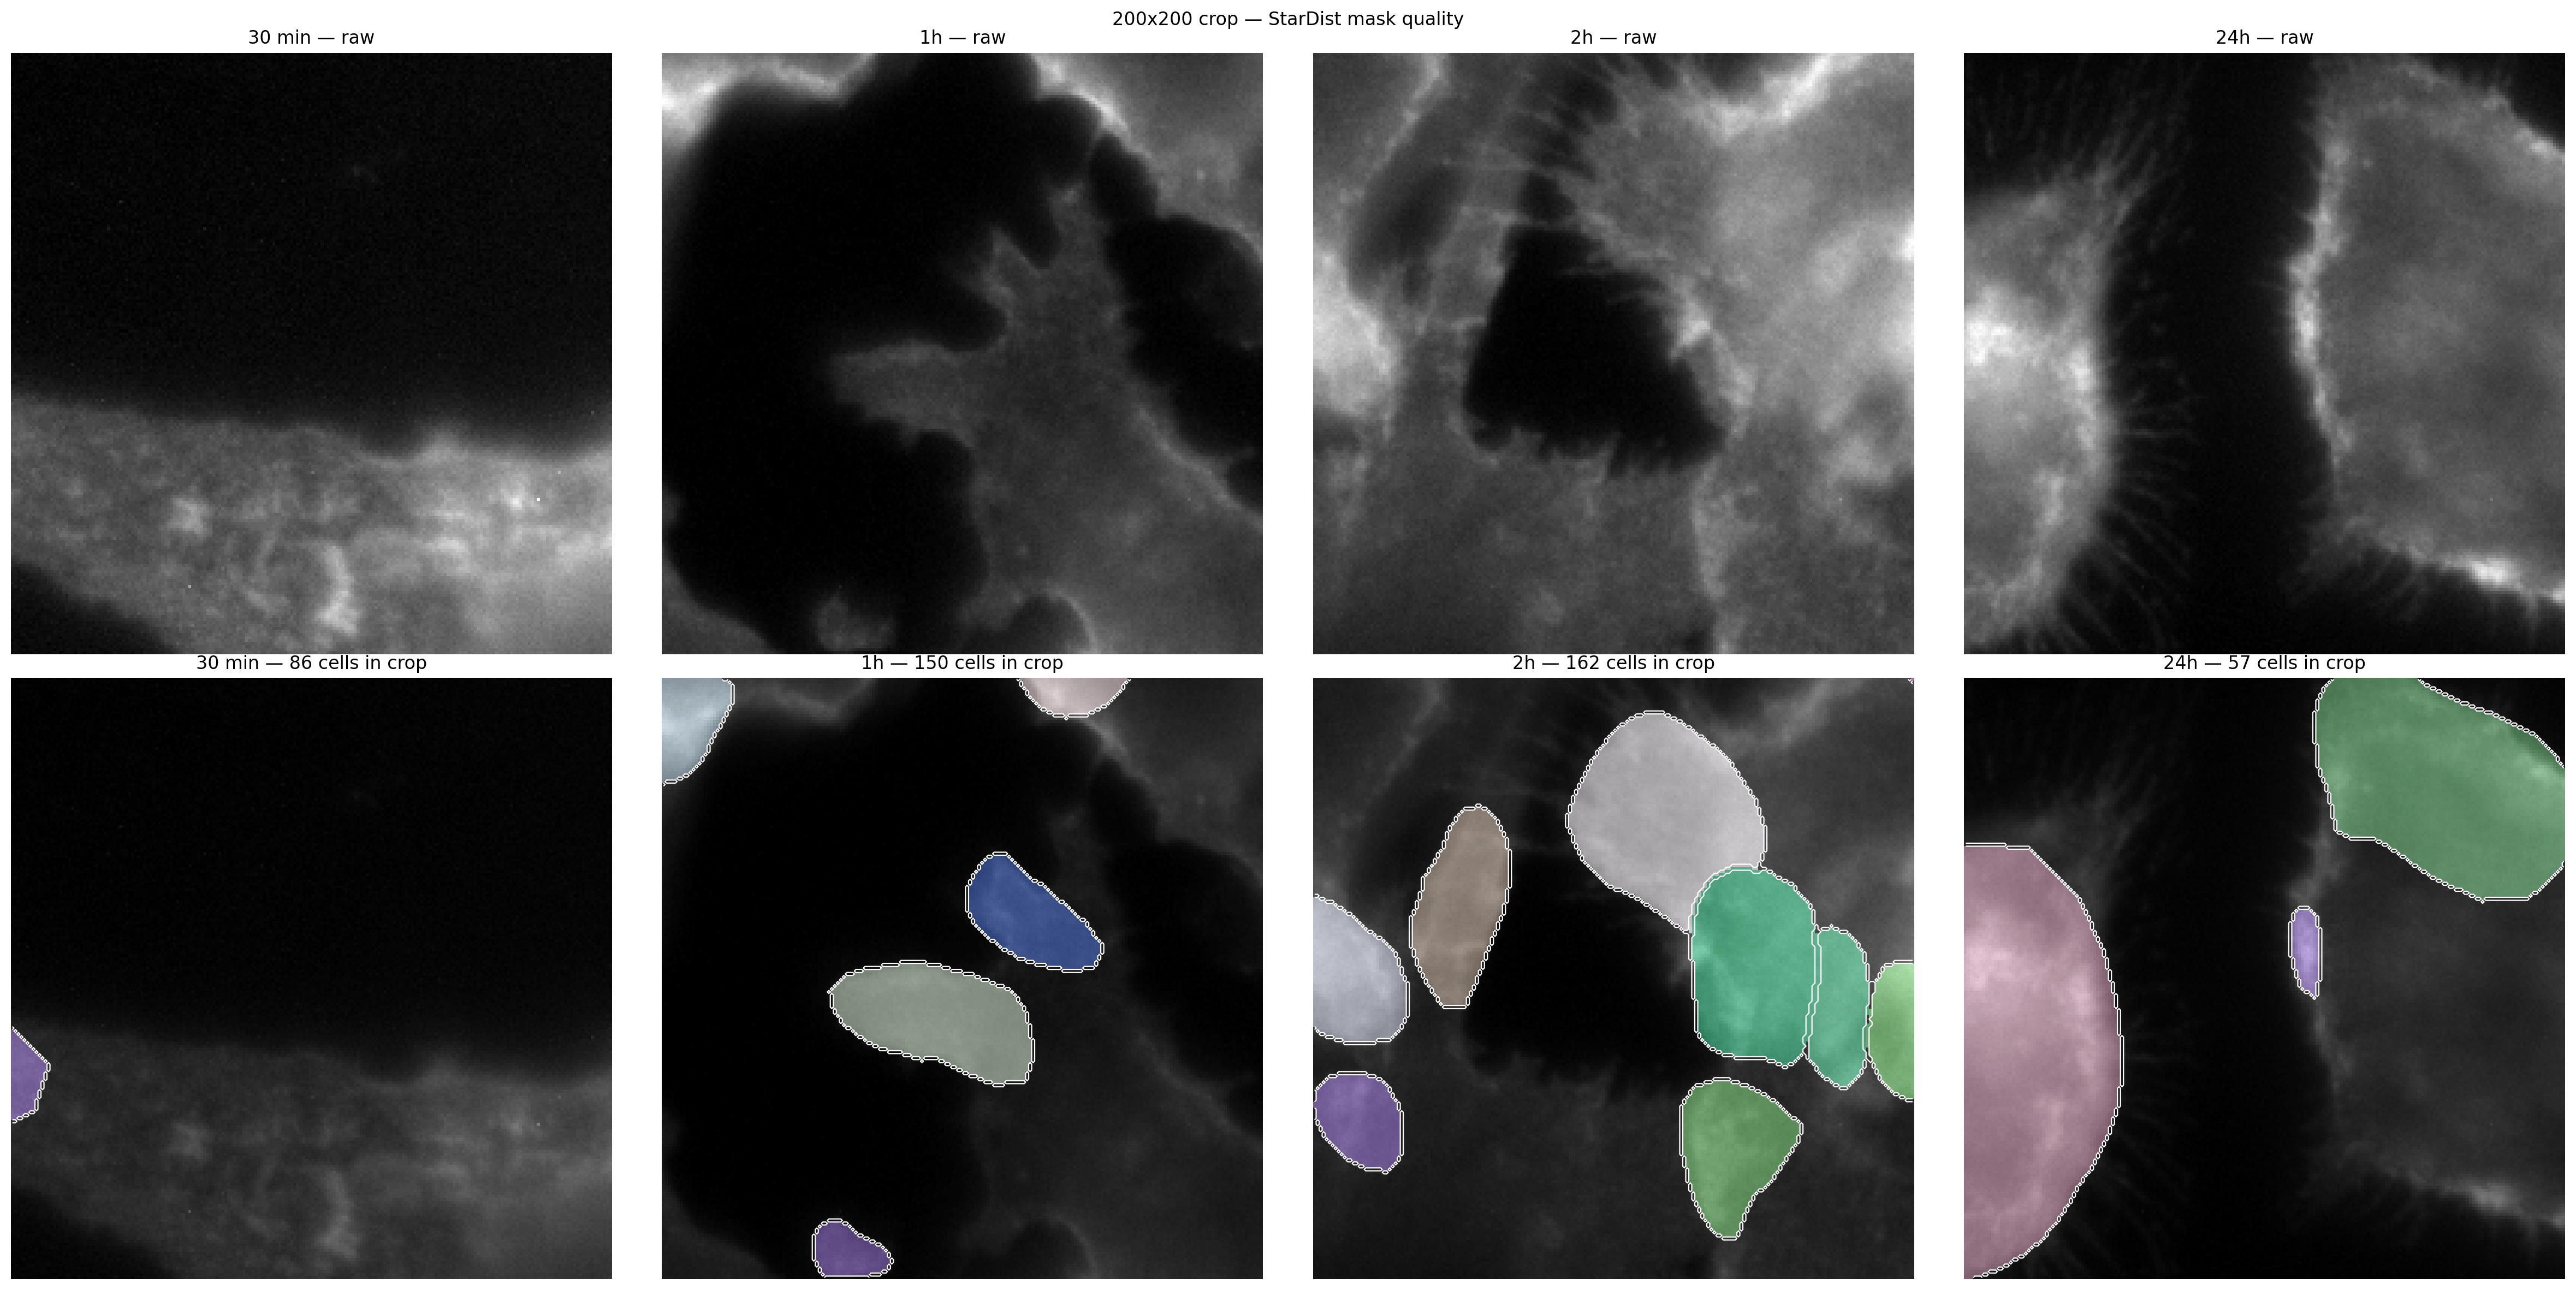

In [30]:
from skimage.segmentation import find_boundaries

x1, y1 = 200, 200
x2, y2 = 400, 400

fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for i, (img, lbl, title) in enumerate(zip(images, labels, titles)):
    img_norm = normalize(img, 1, 99.8, axis=(0,1))
    img_crop = img_norm[y1:y2, x1:x2]
    lbl_crop = lbl[y1:y2, x1:x2]
    
    # top row: raw crop
    axes[0, i].imshow(img_crop, cmap='gray')
    axes[0, i].set_title(f'{title} — raw')
    axes[0, i].axis('off')
    
    # bottom row: mask + outlines
    axes[1, i].imshow(img_crop, cmap='gray')
    axes[1, i].imshow(lbl_crop, cmap=lbl_cmap, alpha=0.5)
    boundaries = find_boundaries(lbl_crop, mode='outer')
    axes[1, i].contour(boundaries, colors='white', linewidths=0.8)
    axes[1, i].set_title(f'{title} — {lbl_crop.max()} cells in crop')
    axes[1, i].axis('off')

plt.suptitle('200x200 crop — StarDist mask quality')
plt.tight_layout()
plt.show()

## Results

**Cell counts and Cf/P (whole image):**
- 30 min: 157 cells — Cf/P 0.000109
- 1h: 252 cells — Cf/P 0.000175
- 2h: 186 cells — Cf/P 0.000129
- 24h: 61 cells — Cf/P 0.000042

Cf/P peaks at 1h then declines steadily through 24h, suggesting either true 
reduction in cell density over time or increasing difficulty in segmentation 
as cells spread and flatten.

**Mask quality observations:**
Visual inspection of the 200×200 crop reveals notable limitations of StarDist 
on these images:

- Masks appear **smaller than the actual cells** — StarDist tends to 
  underestimate cell boundaries, likely because macrophages are large and 
  irregularly shaped
- Mask boundaries **do not closely follow cell shape** — StarDist's 
  star-convex polygon assumption works best for round nuclei; macrophage 
  nuclei can be elongated or irregular, which this model struggles with
- The **30min image** has very low signal intensity, making detection 
  unreliable — 86 cells detected in the crop but many may be false positives 
  on noise
- The **24h image** shows very large cells with the lowest Cf/P, consistent 
  with macrophage spreading over time

> These observations motivate comparison with Cellpose and CellposeSAM, which 
> use different approaches to cell boundary detection and may handle irregular 
> shapes better.

30 min: 157 cells / 1443520 pixels = Cf/P 0.000109
1h: 252 cells / 1443520 pixels = Cf/P 0.000175
2h: 186 cells / 1443520 pixels = Cf/P 0.000129
24h: 61 cells / 1443520 pixels = Cf/P 0.000042


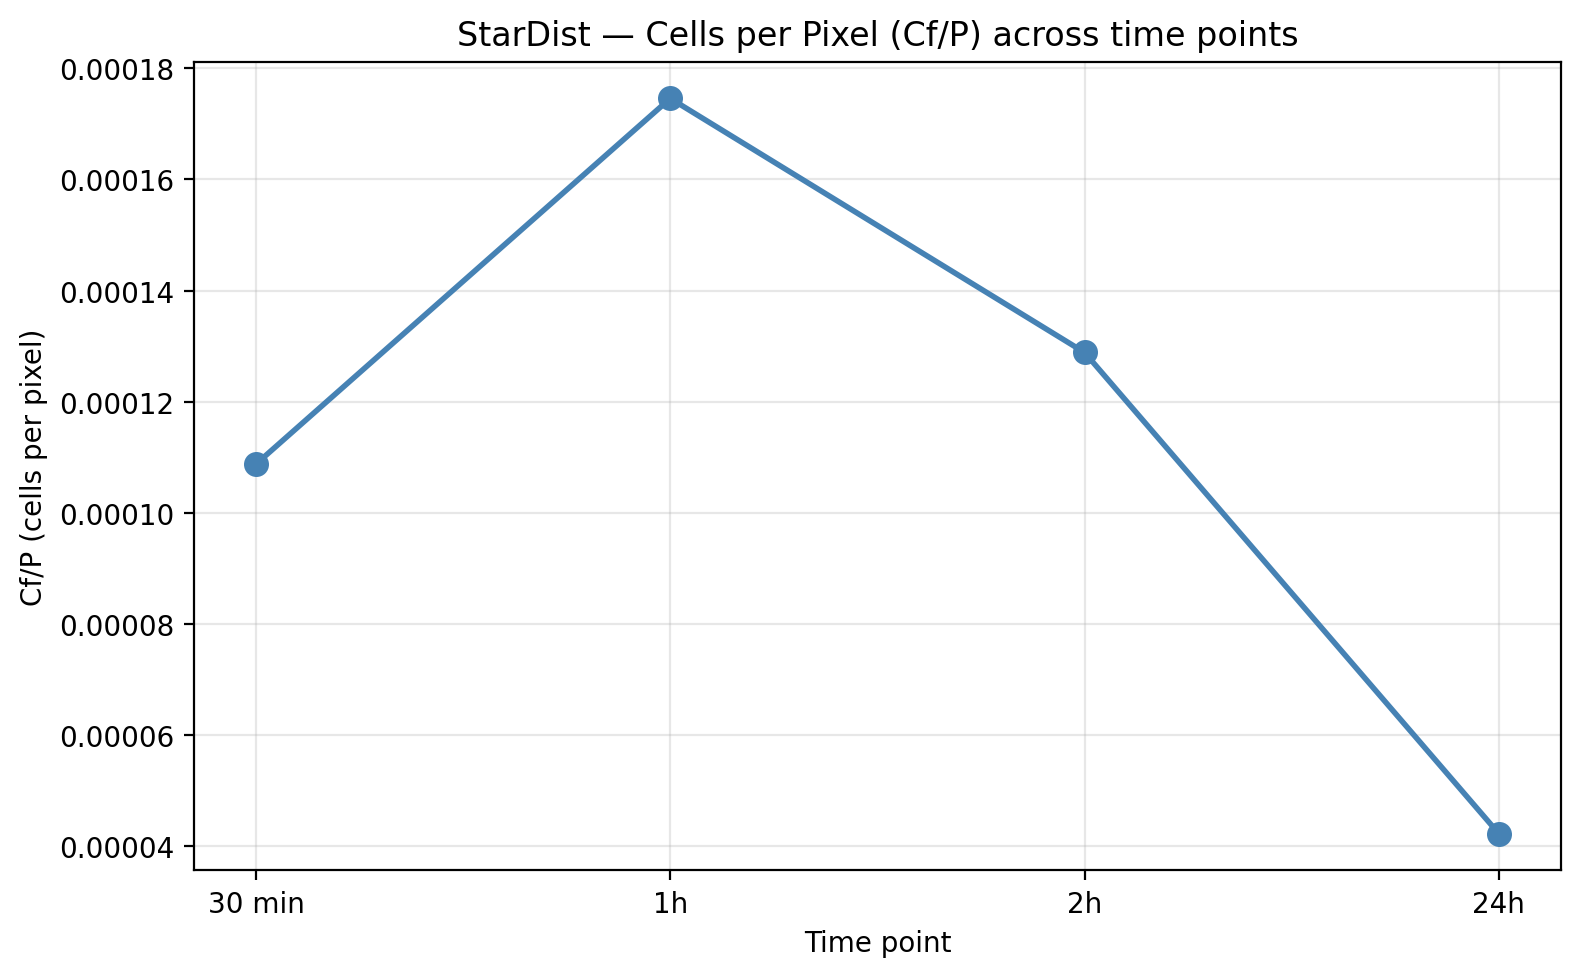

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

cfp_scores = []
for img, lbl, title in zip(images, labels, titles):
    n_cells = lbl.max()
    total_pixels = lbl.shape[0] * lbl.shape[1]
    cfp = n_cells / total_pixels
    cfp_scores.append(cfp)
    print(f"{title}: {n_cells} cells / {total_pixels} pixels = Cf/P {cfp:.6f}")

ax.plot(titles, cfp_scores, marker='o', linewidth=2, color='steelblue', markersize=8)
ax.set_xlabel('Time point')
ax.set_ylabel('Cf/P (cells per pixel)')
ax.set_title('StarDist — Cells per Pixel (Cf/P) across time points')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Notes & Future Directions

- **Tiling:** for larger images, `predict_instances` supports an `n_tiles` 
  parameter to process images in tiles and avoid memory issues
- **Threshold tuning:** `prob_thresh` and `nms_thresh` can be adjusted to 
  trade off sensitivity vs. specificity — lower `prob_thresh` detects more 
  cells but increases false positives
- **GPU:** analysis was run on CPU; GPU would significantly reduce inference time
- **Ground truth:** BBBC020 includes segmentation ground truth masks which 
  could be used to compute IoU and other accuracy metrics against StarDist output
- **Next steps:** repeat analysis with Cellpose and CellposeSAM for direct 
  comparison using the same images and Cf/P metric